# Imports

In [ ]:
df_stocks_view = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/stock_view.csv")

# EDA for stocks

In [ ]:
df_stocks_view.head()

,Unnamed: 0,BvD ID number,Company name Latin alphabet,Year,avg_vol,std_vol,max_vol,min_vol,vol_stability_score,vol_shock_ratio,...,Price_trends_52 weeks_%,market_beta_1y,Earnings_per_share_DKK,Book_value_per_share_DKK,Shares outstanding,Current_market_capitalisation_DKK,avg_closing_price,price_volatility_score,price_trend_slope,Risk level_stock_closing_price
0,0,AE0001327927,Rever Events L.L.C,2011,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
1,1,AE0001327927,Rever Events L.L.C,2012,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
2,2,AE0001327927,Rever Events L.L.C,2013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
3,3,AE0001327927,Rever Events L.L.C,2014,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
4,4,AE0001327927,Rever Events L.L.C,2015,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution


In [ ]:
df_stocks_view.info()

<class 'pandas.DataFrame'>
RangeIndex: 30288 entries, 0 to 30287
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         30288 non-null  int64  
 1   BvD ID number                      30288 non-null  str    
 2   Company name Latin alphabet        30288 non-null  str    
 3   Year                               30288 non-null  int64  
 4   avg_vol                            1064 non-null   float64
 5   std_vol                            1060 non-null   float64
 6   max_vol                            1064 non-null   float64
 7   min_vol                            1064 non-null   float64
 8   vol_stability_score                1059 non-null   float64
 9   vol_shock_ratio                    1064 non-null   float64
 10  vol_trend_slope                    1059 non-null   float64
 11  Join_Year                          30288 non-null  int64  
 12  R

In [ ]:
def clean_eda_columns(df):
    # Columns that should be numeric but are marked as 'str' in your schema
    cols_to_convert = ['Shares outstanding', 'Current_market_capitalisation_DKK']
    
    for col in cols_to_convert:
        if col in df.columns:
            # Remove dots/commas and handle 'n.a.'
            df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_stocks_view = clean_eda_columns(df_stocks_view)

## Statistical Percentiles

In [ ]:
key_signals = [
    'vol_shock_ratio', 'vol_trend_slope', 'market_cap_volatility', 
    'market_beta_1y', 'price_volatility_score', 'price_trend_slope'
]

# Generate detailed statistics
stats_summary = df_stocks_view[key_signals].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])
print("--- Snorkel Threshold Reference Table ---")
print(stats_summary)

--- Snorkel Threshold Reference Table ---
       vol_shock_ratio  vol_trend_slope  market_cap_volatility  \
count      1064.000000      1059.000000            1060.000000   
mean         39.280018         0.009956               0.129503   
std         769.483901         0.182040               0.088402   
min           0.000000        -1.879210               0.000000   
10%           1.714298        -0.047217               0.048644   
25%           2.117816        -0.016506               0.071901   
50%           2.945807         0.004407               0.109410   
75%           5.162125         0.026830               0.158267   
90%          10.205265         0.062724               0.236132   
95%          19.492026         0.131530               0.298709   
99%         244.404761         0.803195               0.479828   
max       24696.395897         2.000000               0.683626   

       market_beta_1y  price_volatility_score  price_trend_slope  
count     1392.000000           

## Distribution Plots

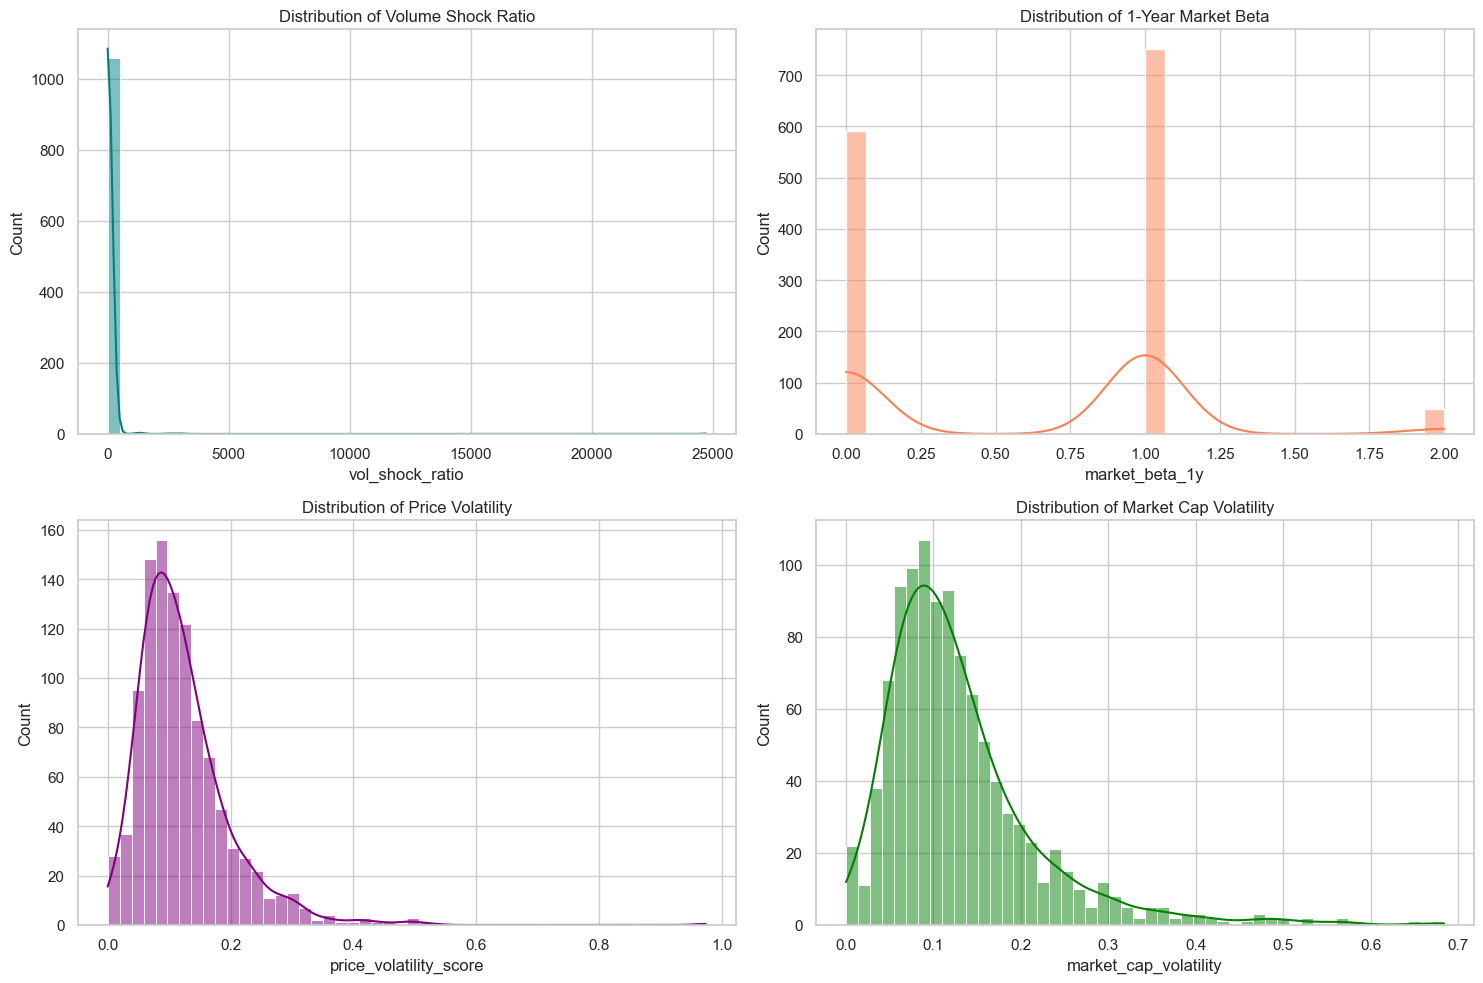

In [ ]:
# Set visual 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (15, 10)

fig, axes = plt.subplots(2, 2)

# Volume Shock 
sns.histplot(df_stocks_view['vol_shock_ratio'].dropna(), bins=50, kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Distribution of Volume Shock Ratio')

# Market Beta 
sns.histplot(df_stocks_view['market_beta_1y'].dropna(), bins=30, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('Distribution of 1-Year Market Beta')

# Price Volatility (Market Sentiment)
sns.histplot(df_stocks_view['price_volatility_score'].dropna(), bins=50, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Distribution of Price Volatility')

# Market Cap Volatility (Size Stability)
sns.histplot(df_stocks_view['market_cap_volatility'].dropna(), bins=50, kde=True, ax=axes[1,1], color='green')
axes[1,1].set_title('Distribution of Market Cap Volatility')

plt.tight_layout()
plt.show()

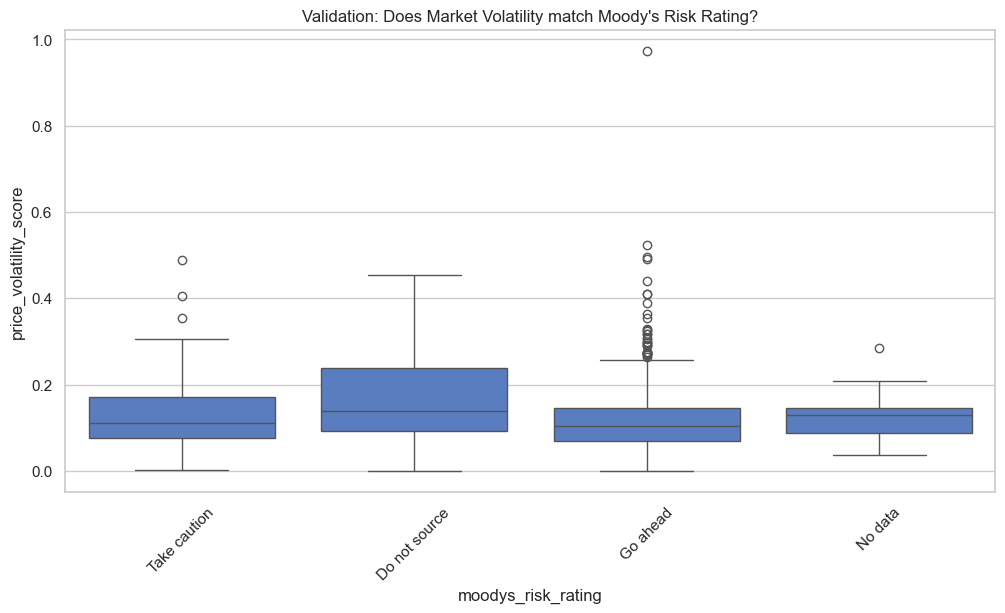

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_stocks_view, x='moodys_risk_rating', y='price_volatility_score')
plt.title('Validation: Does Market Volatility match Moody\'s Risk Rating?')
plt.xticks(rotation=45)
plt.show()

## Correlation heatmap

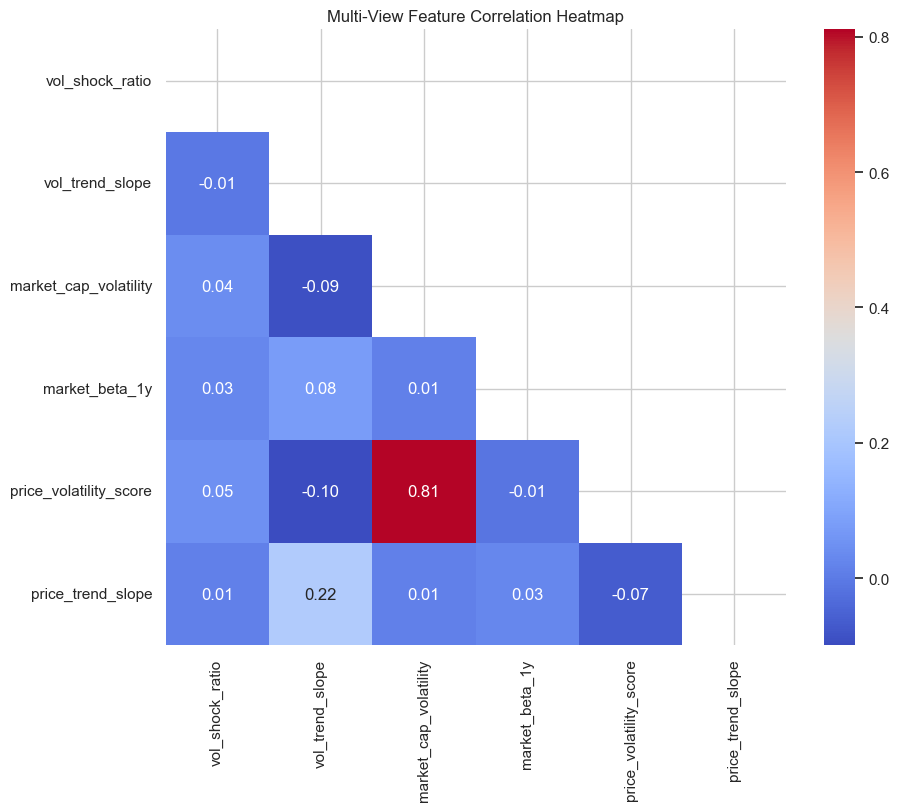

In [ ]:
plt.figure(figsize=(10, 8))
corr = df_stocks_view[key_signals].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Only show bottom half
sns.heatmap(corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f")
plt.title('Multi-View Feature Correlation Heatmap')
plt.show()